# Test preprocessing pipeline here

-e .
mne, mne_icalabel
ipykernel
onnxruntime
pyprep, meegkit

In [ ]:
import mne
import os
from speed.pipeline_challenge import BasePipeline, PretrainPipeline
from pathlib import Path

In [5]:
raw_path  = "/data/agjma/HBN_EEG_Raw/ds005505/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set" 
assert os.path.exists(raw_path), f"File {raw_path} does not exist."
print(f"File {raw_path} exists.")

File /data/agjma/HBN_EEG_Raw/ds005505/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set exists.


In [6]:
# raw = mne.io.read_raw_eeglab(raw_path, preload=True)
# print(raw.ch_names)
hbn_channels = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'Cz']

In [7]:
# import logging

# logging.basicConfig(
#     level=logging.DEBUG,   # or INFO if you don’t want debug spam
#     format="%(asctime)s [%(levelname)s] %(message)s",
#     force=True             # overwrite any previous logging config
# )
# import sys
# logging.basicConfig(stream=sys.stdout, level=logging.DEBUG, force=True)


In [ ]:
pipeline = PretrainPipeline(
    do_ica=False, 
    line_freqs=60, 
    channels_rename=None, 
    montage_name=None, 
    channels=hbn_channels, 
    window_length=None, ########################################################
    metrics_path=Path("logs"), 
    hp_freq=0.5,
    lp_freq=50,
    return_quality_metrics=True,
    drop_bad_quality=False,
    channels_to_remove=['E48', 'E49', 'E56', 'E63', 'E68', 'E73', 'E81', 'E88', 'E94', 'E99', 'E107', 'E113', 'E119', 'E1', 'E8', 'E14', 'E17', 'E21', 'E25', 'E32', 'E125', 'E126', 'E127', 'E128']
    )
# figure out none in window length


In [9]:
raws, times, indices = pipeline([raw_path], )

DEBUG:root:Loading EDF files...
DEBUG:root:Splitting raws...
INFO:root:File: sub-NDARAC904DMU_task-RestingState_eeg.	Manually dropped 24 channels: ['E48', 'E49', 'E56', 'E63', 'E68', 'E73', 'E81', 'E88', 'E94', 'E99', 'E107', 'E113', 'E119', 'E1', 'E8', 'E14', 'E17', 'E21', 'E25', 'E32', 'E125', 'E126', 'E127', 'E128'].
DEBUG:root:Total windows: 1


/home/linsk/.conda/envs/challenge/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:root:File: /data/agjma/HBN_EEG_Raw/ds005505/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set.	Time: (np.float64(0.0), np.float64(403.5)).	Found 16 bad channels: ['E39', 'E122', np.str_('E80'), 'E44', 'E18', 'E53', 'E22', 'E38', 'E26', 'Cz', 'E55', np.str_('E6'), 'E43', 'E67', np.str_('E103'), 'E114'].
INFO:root:File: /data/agjma/HBN_EEG_Raw/ds005505/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set.	Time: (np.float64(0.0), np.float64(403.5)).	Intepolating 16 channels: ['E39', 'E80', 'E122', 'E44', 'E18', 'E53', 'E55', 'E26', 'E38', 'E22', 'E6', 'Cz', 'E43', 'E67', 'E103', 'E114'].


# check manually if file looks okay: 


In [6]:
# load hdf5 file: 
import h5py
import numpy as np

data1_path = "/data/linsk/temp_prep/data_1.hdf5"

In [24]:
# load: 

with h5py.File(data1_path, 'r') as f:
    # print(dict(f.attrs).keys())
    data = f['data'][:]
    print(data.shape) # (windows, 105, 3000)
 

(9, 105, 3000)


In [27]:
data

array([[[ 2.00134055e-20,  1.44805244e-05,  1.34728825e-05, ...,
          1.46994589e-05,  1.60877225e-05,  1.98380417e-06],
        [-3.15384596e-22,  1.33157309e-05,  1.38136447e-05, ...,
          4.69458519e-06,  2.26258203e-06, -1.18991989e-06],
        [ 1.49312078e-20,  1.46803877e-05,  1.41605506e-05, ...,
          3.85167505e-06,  1.97497229e-06, -2.29800708e-06],
        ...,
        [-8.78571389e-21,  9.45357715e-06,  8.46508465e-06, ...,
          6.66753749e-06,  3.98024849e-06,  4.95227937e-07],
        [-7.09164800e-21,  1.13274536e-05,  1.13050128e-05, ...,
          4.94765482e-06,  3.17593435e-06, -1.82682777e-06],
        [ 1.90032338e-20, -1.37538755e-05, -8.42568897e-06, ...,
          8.73489114e-07, -1.65053154e-06,  7.26436156e-07]],

       [[ 6.19335934e-21, -1.96639467e-05, -2.67417345e-05, ...,
          7.71255236e-06, -5.11013059e-06, -3.34108472e-06],
        [-9.90026707e-21, -7.63022126e-06, -1.26296627e-05, ...,
          4.67340124e-06, -2.55359760e

Creating RawArray with float64 data, n_channels=105, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    29.990 secs
Ready.


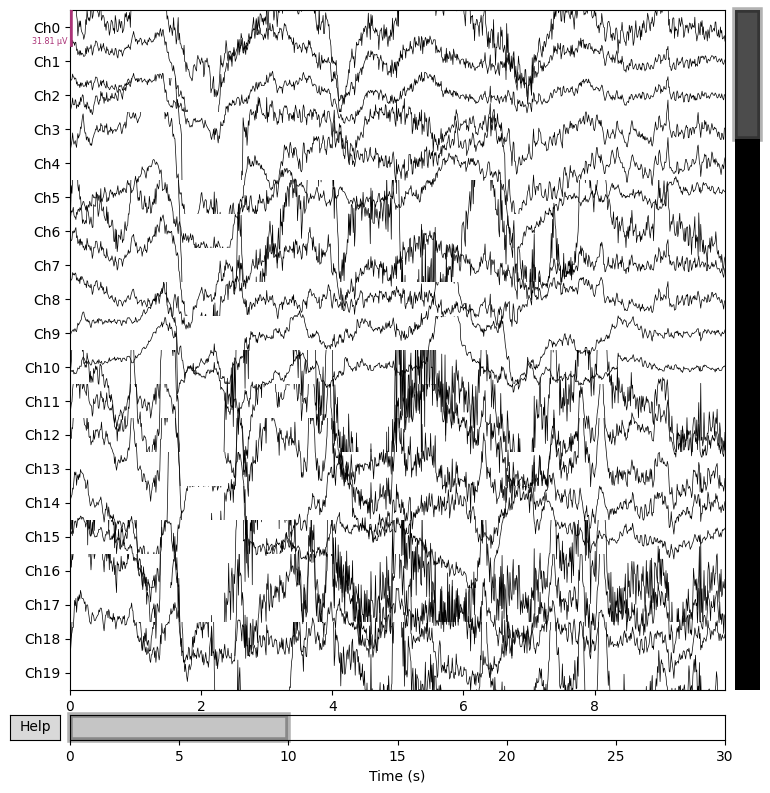

''

In [32]:
import mne

window_idx = 0
eeg_data = data[window_idx] 

sfreq = 100 
ch_names = [f"Ch{i}" for i in range(eeg_data.shape[0])]
ch_types = ["eeg"] * eeg_data.shape[0]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(eeg_data, info)

raw.plot(scalings='auto', title=f"Window {window_idx}", show=True)
;
